In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x : f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update(
    {
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize":8,
        "ytick.labelsize":8
    }
)
RANDOM_STATE = 42
CSV_PATH = r"C:\Users\Sufiyan\Downloads\Datasets\housing.csv"
TARGET_COL = "median_house_value"

In [4]:
df = pd.read_csv(CSV_PATH)

In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


In [6]:
print("DataFrame Shape :",df.shape)

DataFrame Shape : (20640, 10)


# EDA

In [7]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
num_cols = df.select_dtypes("number").columns.to_list()
cat_cols = df.select_dtypes("object").columns.tolist()

In [10]:
print("Numerical Columns ", num_cols)
print("Catgorical Columns ", cat_cols)
print("Target Column ", TARGET_COL)

Numerical Columns  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Catgorical Columns  ['ocean_proximity']
Target Column  median_house_value


# Missing Value Analysis

In [11]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [12]:
for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.250    128
-118.370    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
33.980    162
34.110    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.000,-119.570,2.004,-124.350,-121.800,-118.490,-118.010,-114.310
latitude,20640.000,35.632,2.136,32.540,33.930,34.260,37.710,41.950
housing_median_age,20640.000,28.639,12.586,1.000,18.000,29.000,37.000,52.000
total_rooms,20640.000,2635.763,2181.615,2.000,1447.750,2127.000,3148.000,39320.000
total_bedrooms,20433.000,537.871,421.385,1.000,296.000,435.000,647.000,6445.000
population,20640.000,1425.477,1132.462,3.000,787.000,1166.000,1725.000,35682.000
households,20640.000,499.540,382.330,1.000,280.000,409.000,605.000,6082.000
median_income,20640.000,3.871,1.900,0.500,2.563,3.535,4.743,15.000
median_house_value,20640.000,206855.817,115395.616,14999.000,119600.000,179700.000,264725.000,500001.000


# Data Visualization

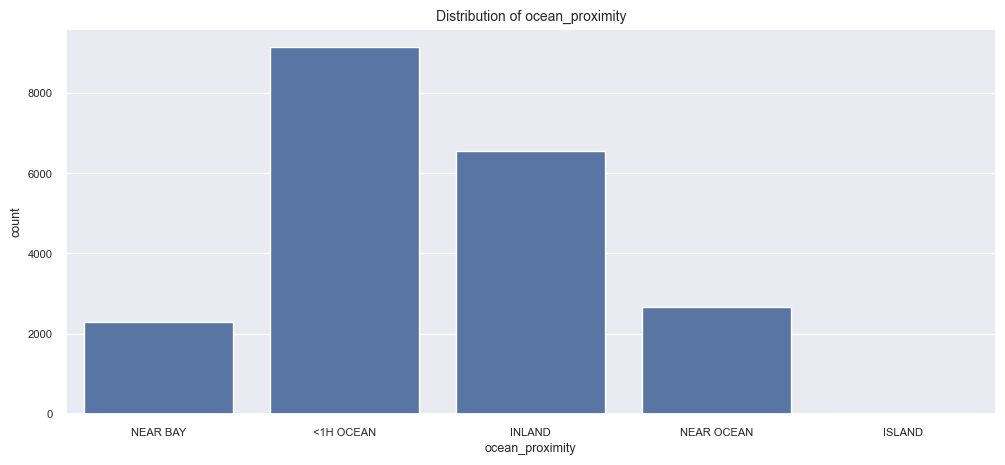

In [15]:
for col in cat_cols:
    plt.figure(figsize=(12,5))
    sns.countplot(data=df , x=col)
    plt.title(f"Distribution of {col}")
    plt.show()

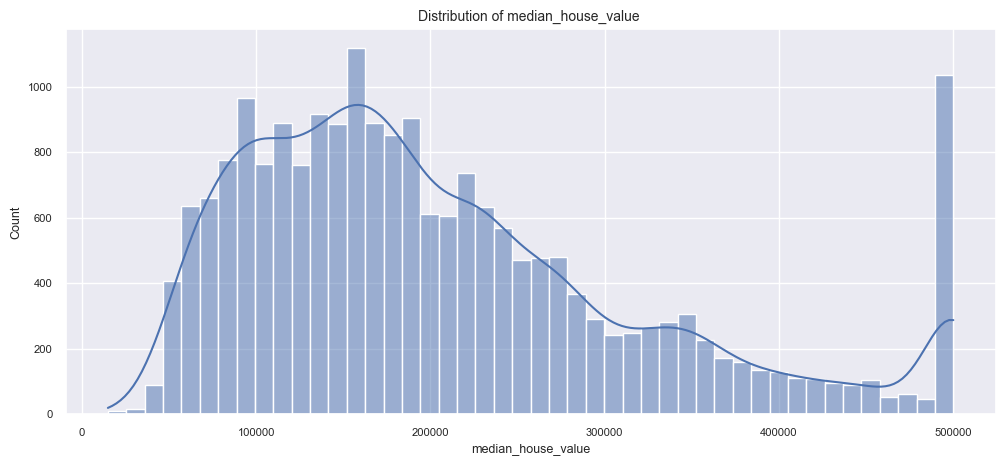

In [16]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x=TARGET_COL, kde=True)
plt.title("Distribution of {} ".format(TARGET_COL))
plt.show()

In [17]:
df[TARGET_COL].value_counts()

median_house_value
500001.000    965
137500.000    122
162500.000    117
112500.000    103
187500.000     93
             ... 
34200.000       1
46200.000       1
352000.000      1
307900.000      1
385200.000      1
Name: count, Length: 3842, dtype: int64

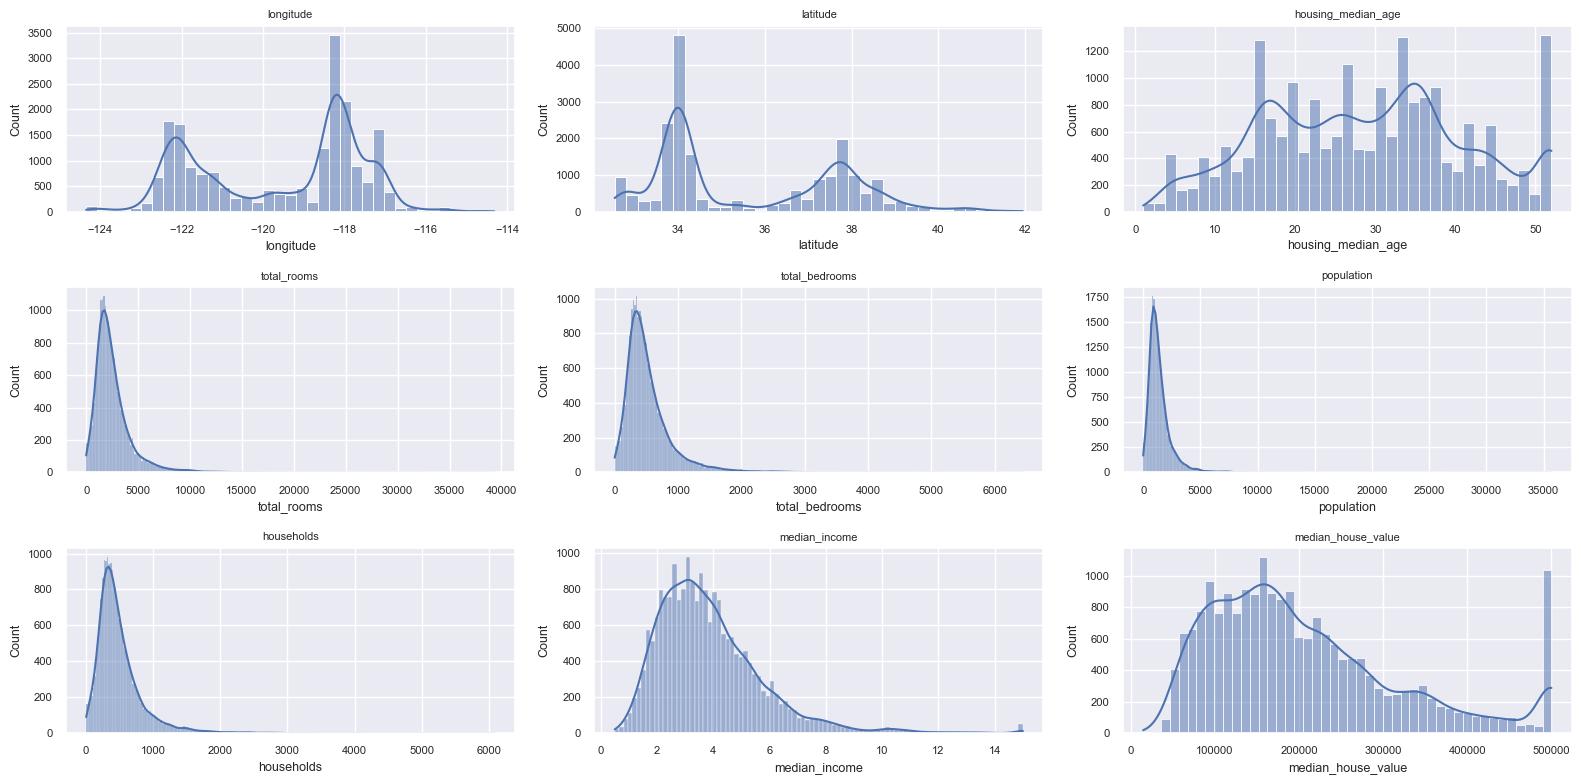

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(16,8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)
plt.tight_layout()
plt.show()

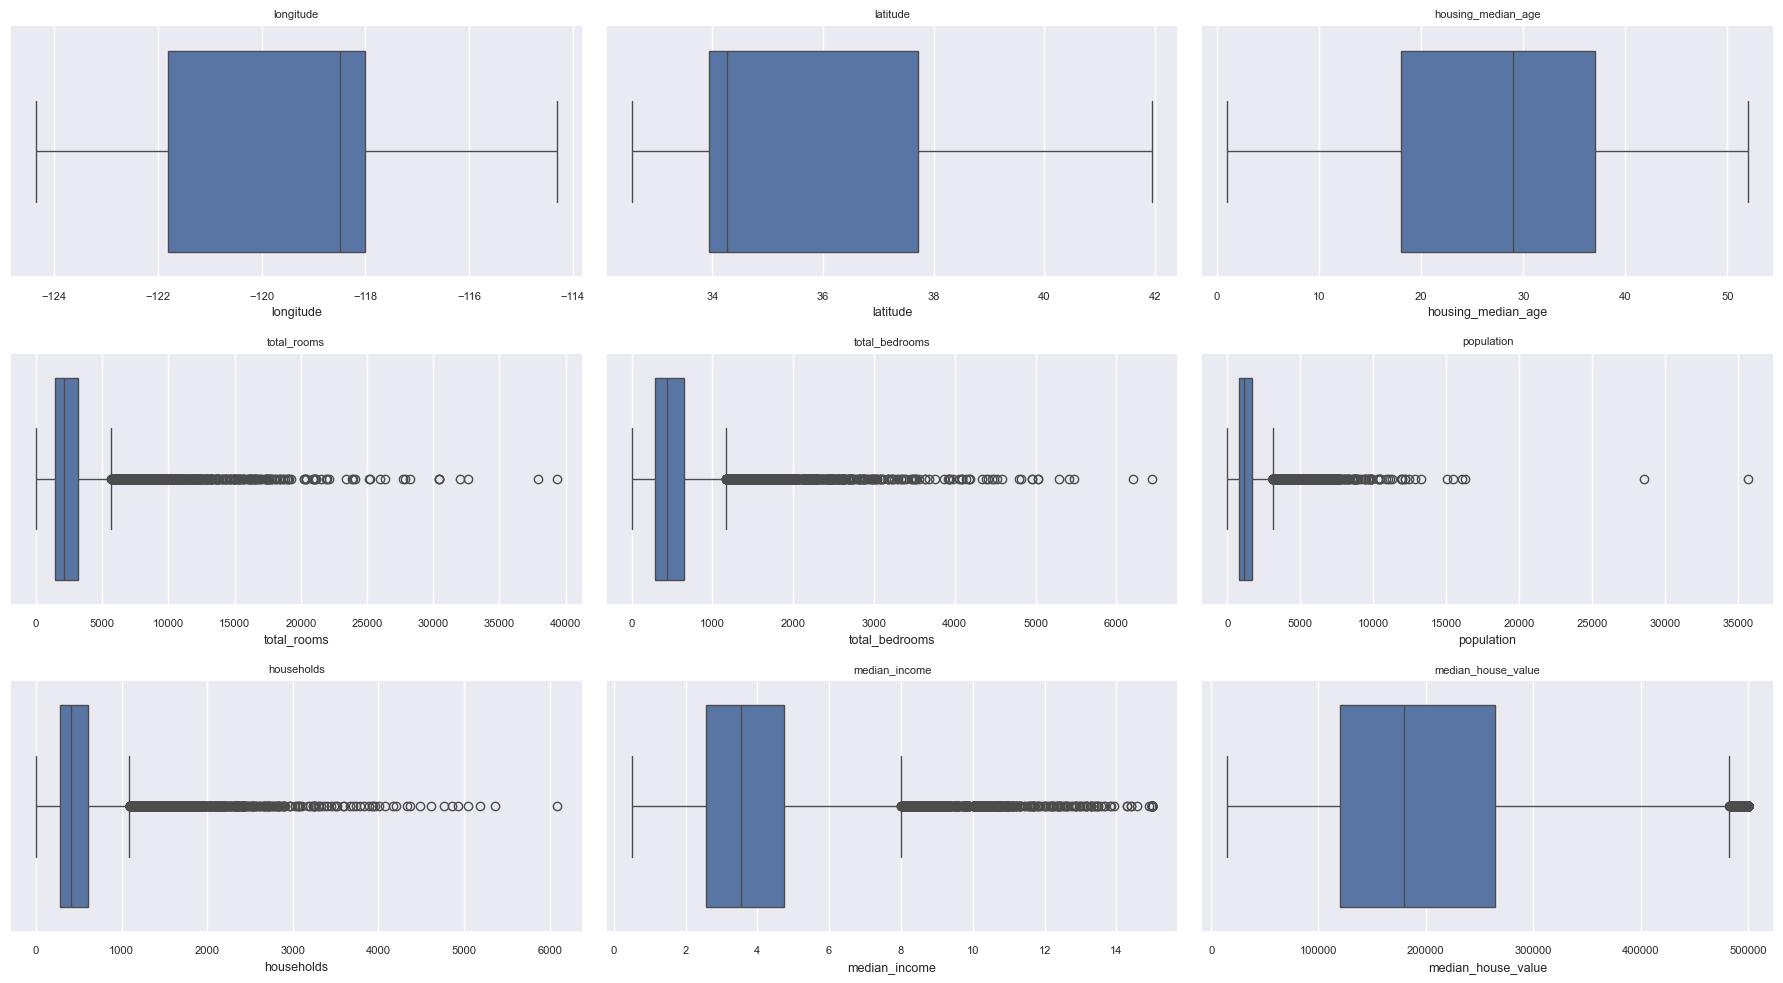

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(18,10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()


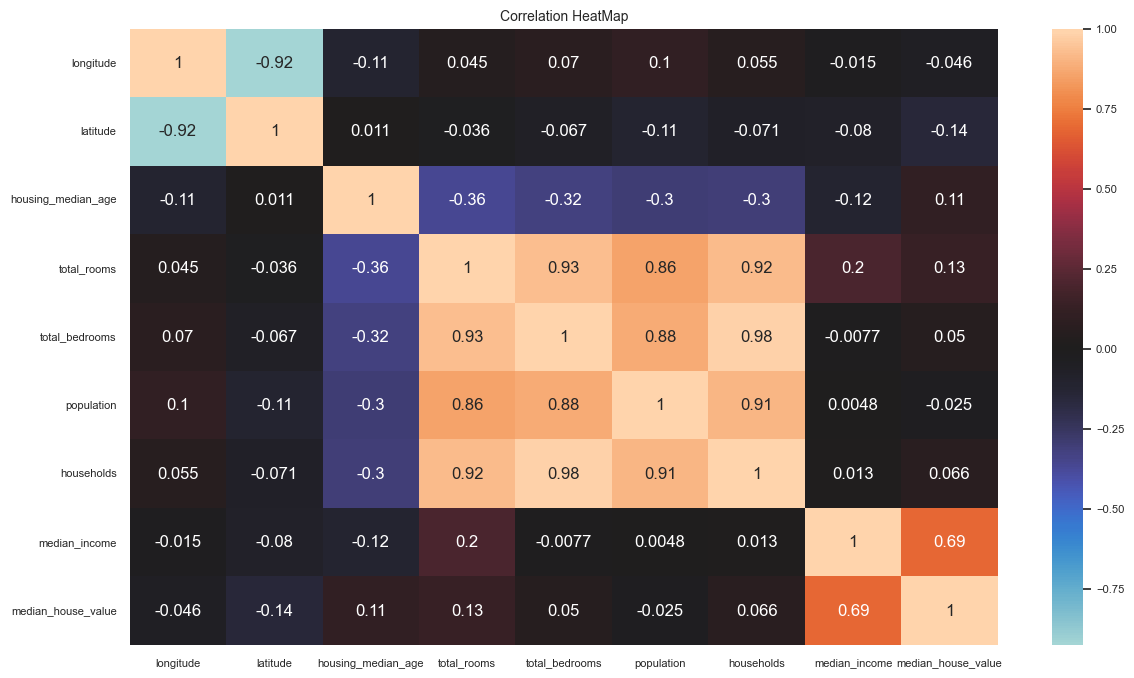

In [20]:
plt.figure(figsize=(14,8))
sns.heatmap(df[num_cols].corr(), annot=True,center=0)
plt.title("Correlation HeatMap")
plt.show()

# Data Preprocessing

In [21]:
x = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [22]:
x.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [23]:
y.head()

0   452600.000
1   358500.000
2   352100.000
3   341300.000
4   342200.000
Name: median_house_value, dtype: float64

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2 , random_state=RANDOM_STATE)

In [25]:
print("x_train shape", x_train.shape)
print("x_test shape", x_test.shape)

x_train shape (16512, 9)
x_test shape (4128, 9)


In [26]:
print("y_train shape", y_train.shape)
print("y_test shape", y_test.shape)

y_train shape (16512,)
y_test shape (4128,)


In [27]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.090,39.480,25.000,1665.000,374.000,845.000,330.000,1.560,78100.000,INLAND
20636,-121.210,39.490,18.000,697.000,150.000,356.000,114.000,2.557,77100.000,INLAND
20637,-121.220,39.430,17.000,2254.000,485.000,1007.000,433.000,1.700,92300.000,INLAND
20638,-121.320,39.430,18.000,1860.000,409.000,741.000,349.000,1.867,84700.000,INLAND


In [28]:
num_cols = x_train.select_dtypes(include='number').columns.tolist()
cat_cols = x_train.select_dtypes(include='object').columns.tolist()

In [29]:
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [30]:
categorical_transformer = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])

In [31]:
preprocess = ColumnTransformer(transformers=[
    ("numerical", numerical_transformer, num_cols),
    ("categorical", categorical_transformer, cat_cols)
])

# Baseline Model

In [32]:
baseline_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression()) 
])

In [33]:
baseline_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tra

In [34]:
train_baseline_pred = baseline_model.predict(x_train)
test_baseline_pred = baseline_model.predict(x_test)

In [35]:
y_train[:5]

14196   103000.000
8267    382100.000
17445   172600.000
14265    93400.000
2271     96500.000
Name: median_house_value, dtype: float64

In [36]:
print("Train Baseline Metrics\n")
print("RMSE : ", root_mean_squared_error(y_train, train_baseline_pred))
print("MSE : ", mean_absolute_error(y_train, train_baseline_pred))
print("R2 : ", r2_score(y_train, train_baseline_pred))

Train Baseline Metrics

RMSE :  68433.93736666226
MSE :  49594.842094724365
R2 :  0.6496648627123224


In [37]:
print("Test Baseline Metrics\n")
print("RMSE : ", root_mean_squared_error(y_test, test_baseline_pred))
print("MSE : ", mean_absolute_error(y_test, test_baseline_pred))
print("R2 : ", r2_score(y_test, test_baseline_pred))

Test Baseline Metrics

RMSE :  70059.19333925014
MSE :  50670.48923565362
R2 :  0.6254382675296266


In [38]:
models = {
    "lr" : LinearRegression(),
    "lasso" : Lasso(random_state = RANDOM_STATE, max_iter=10000),
    "ridge" : Ridge(random_state = RANDOM_STATE),
    "rfr" : RandomForestRegressor(),
    "gbr" : HistGradientBoostingRegressor()

}

In [39]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)


In [40]:
scoring = {
    "rmse" : "neg_root_mean_squared_error",
    "mae" : "neg_mean_absolute_error",
    "r2" : "r2"
}

In [44]:
rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])
    score = cross_validate(pipe, x_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "Model" : model,
        "cv_rmse" : -score["test_rmse"].mean(),
        "cv_mae" : -score["test_mae"].mean(),
        "cv_r2" : -score["test_r2"].mean(),
    })

In [47]:
pd.DataFrame(rows).sort_values("cv_rmse")

,Model,cv_rmse,cv_mae,cv_r2
4,HistGradientBoostingRegressor(),48139.936,32400.134,-0.827
3,RandomForestRegressor(),49416.056,32267.924,-0.817
2,Ridge(random_state=42),68595.617,49664.331,-0.648
1,"Lasso(max_iter=10000, random_state=42)",68603.233,49667.263,-0.648
0,LinearRegression(),68604.163,49667.159,-0.648


# Best Model : HistGradientBoosting